---
aliases:
- /2026/04/spt3g-d1-planck-comparison
categories:
- cosmology
- python
date: '2026-04-21'
description: Load and compare the SPT-3G D1 high-ell TT power spectra with the Planck 2018 CMB power spectrum, illustrating primary vs. secondary CMB anisotropies.
output-file: 2026-04-21-spt3g-d1-planck-comparison.html
title: SPT-3G D1 high-ℓ CMB power spectra vs. Planck 2018
---

# SPT-3G D1 high-ℓ CMB power spectra vs. Planck 2018

## Background

The **Cosmic Microwave Background (CMB)** temperature anisotropy power spectrum
is usually expressed as $D_\ell = \ell(\ell+1)C_\ell/(2\pi)$ in units of $\mu\mathrm{K}^2$.
It encodes the statistical properties of tiny temperature fluctuations imprinted
on the CMB at recombination ($z \approx 1100$) and provides our most precise
probe of cosmological parameters.

The power spectrum can be divided into two regimes by the physical processes
responsible for the signal:

### Primary anisotropies ($\ell \lesssim 2500$)

These arise from density and velocity perturbations in the primordial plasma.
The characteristic acoustic peaks at $\ell \approx 200, 500, 800, \ldots$ are
perfectly measured by **Planck** (Planck Collaboration 2020).

### Secondary anisotropies ($\ell \gtrsim 2000$)

At smaller angular scales, primary CMB fluctuations are exponentially suppressed
by Silk damping. A rich variety of physical processes contributes instead:

| Effect | Abbreviation | Physical origin |
|--------|-------------|----------------|
| Thermal Sunyaev–Zel'dovich | tSZ | Inverse Compton scattering off hot ICM electrons |
| Kinematic Sunyaev–Zel'dovich | kSZ | Doppler shift from bulk motions of ionized gas |
| Cosmic Infrared Background | CIB | Cumulative emission from dusty star-forming galaxies |
| Radio galaxies | RG | Synchrotron emission from AGN |

The tSZ effect has a distinctive frequency spectrum (decreasing below 217 GHz,
rising above), which means multi-frequency observations can separate it from
the CIB. The kSZ effect has the same frequency spectrum as the CMB and can only
be separated statistically.

## The SPT-3G D1 data set

The **South Pole Telescope** (SPT) is a 10-meter microwave telescope at the
South Pole, operated by a collaboration led by the University of Chicago.
The SPT-3G receiver observes simultaneously at **95, 150, and 220 GHz** with
~16,000 detectors.

Chaubal et al. (2026) present the SPT-3G D1 TT high-ℓ power spectra using
observations from **2019 and 2020** of the 1646 deg² SPT-3G Main field.
The measurements span **1700 ≤ ℓ ≤ 11,000** across six frequency
auto- and cross-spectra:
95×95, 95×150, 95×220, 150×150, 150×220, 220×220 GHz.

> **Citation:** Chaubal P. et al. 2026, *SPT-3G D1: A Measurement of Secondary
> Cosmic Microwave Background Anisotropy Power*, arXiv:2601.20551.
> Data hosted at [LAMBDA](https://lambda.gsfc.nasa.gov/product/spt/spt3g_d1_high_ell_info.html)
> and [UChicago SPT site](https://pole.uchicago.edu/public/data/chaubal26/).

In this notebook we:

1. Download and parse the SPT-3G D1 band powers.
2. Download the Planck 2018 (PR3) binned TT spectrum.
3. Compare the two datasets to visualise how SPT-3G extends the CMB power
   spectrum into the secondary-anisotropy regime.

## Requirements

This notebook uses only the standard scientific Python stack.
The cell below installs the dependencies with `pip` (the standard way to
declare and install notebook requirements).

To run this notebook in an isolated [uv](https://github.com/astral-sh/uv)
virtual environment:

```bash
uv venv .venv
source .venv/bin/activate
uv pip install notebook
jupyter execute 2026-04-21-spt3g-d1-planck-comparison.ipynb
```

The `%pip install` cell below is the standard Jupyter mechanism for
embedding package requirements directly inside a notebook.

In [1]:
%pip install numpy matplotlib requests

/home/zonca/p/software/zonca.dev/posts/.venv-spt3g/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import requests

# Consistent, publication-friendly style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1. Load the SPT-3G D1 band powers

The released text file `dls.txt` contains 144 rows (24 per frequency
combination) with four columns:

| Column | Meaning |
|--------|---------|
| index  | Band index (0-based within each spectrum) |
| ℓ      | Effective multipole of the band |
| $D_\ell$ | Band power $\ell(\ell+1)C_\ell/(2\pi)$ in $\mu\mathrm{K}^2$ |
| $\sigma D_\ell$ | $1\sigma$ uncertainty (diagonal covariance) |

Rows are ordered: all 95×95 bands, then 95×150, 95×220, 150×150,
150×220, 220×220.

In [3]:
SPT_URL = "https://pole.uchicago.edu/public/data/chaubal26/dls.txt"

resp = requests.get(SPT_URL, timeout=30)
resp.raise_for_status()
raw = np.loadtxt(io.StringIO(resp.text))

print(f"Shape: {raw.shape}  →  {raw.shape[0]} rows, {raw.shape[1]} columns")
print(f"Rows per frequency combination: {raw.shape[0] // 6}")

Shape: (144, 4)  →  144 rows, 4 columns
Rows per frequency combination: 24


In [4]:
FREQS = ["95×95", "95×150", "95×220", "150×150", "150×220", "220×220"]
N_BANDS = raw.shape[0] // len(FREQS)  # 24 bands per spectrum

# Split into a dict keyed by frequency label
spt = {}
for i, name in enumerate(FREQS):
    chunk = raw[i * N_BANDS : (i + 1) * N_BANDS]
    spt[name] = {
        "ell":    chunk[:, 1],
        "Dl":     chunk[:, 2],
        "sigmaDl": chunk[:, 3],
    }

# Sanity check
for name, d in spt.items():
    print(f"{name}: ℓ = {d['ell'][0]:.0f} – {d['ell'][-1]:.0f}  "
          f"({N_BANDS} bands)")

95×95: ℓ = 1751 – 10379  (24 bands)
95×150: ℓ = 1752 – 10402  (24 bands)
95×220: ℓ = 1751 – 10411  (24 bands)
150×150: ℓ = 1752 – 10430  (24 bands)
150×220: ℓ = 1751 – 10449  (24 bands)
220×220: ℓ = 1752 – 10436  (24 bands)


## 2. Visualise all six SPT-3G D1 spectra

Each panel shows $D_\ell$ with $\pm 1\sigma$ error bars. The colour coding
follows frequency: blue → 95 GHz, green → 150 GHz, red → 220 GHz.

Key features to notice:

* **Declining slope at low ℓ (~2000–3000):** residual primary CMB power
  (the damping tail).
* **Minimum near ℓ ≈ 3000:** tSZ has a null at ~217 GHz and suppresses
  the 150×150 spectrum, creating a local minimum.
* **Rising power at high ℓ (>4000):** CIB dominates the 220 GHz channels;
  radio galaxies (flat or rising spectra) appear in lower frequency channels.
* **Cross-spectra help separate components:** the 95×220 cross-spectrum,
  for example, is sensitive to the CIB without the noise penalty of a
  220×220 auto-spectrum.

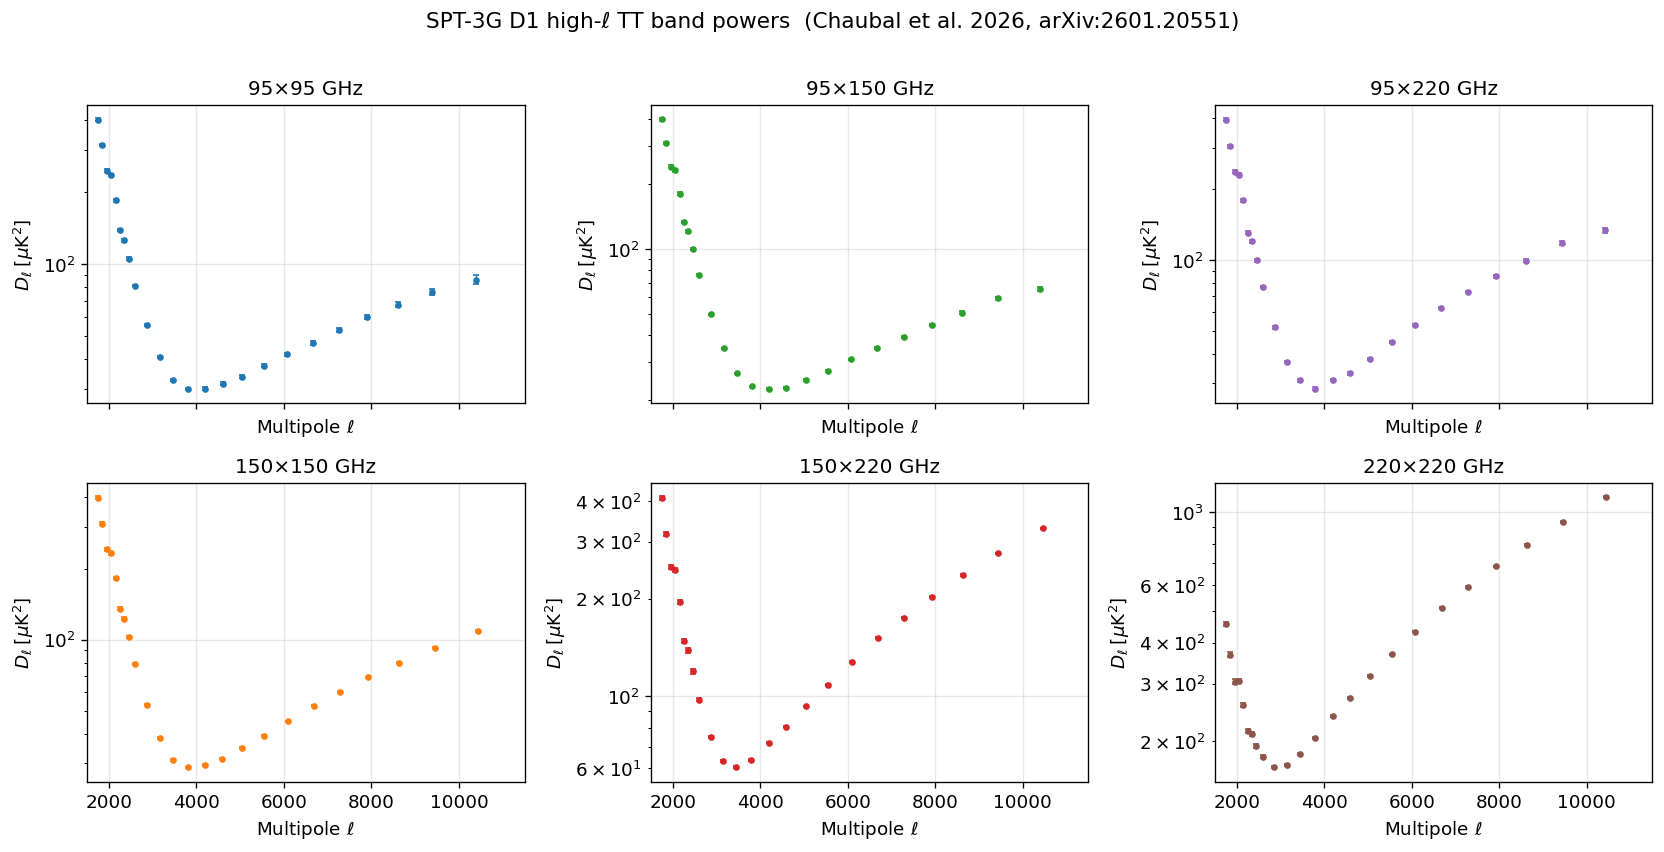

In [5]:
# Colour map: one colour per unique frequency pair
palette = {
    "95×95":   "#1f77b4",   # blue
    "95×150":  "#2ca02c",   # green
    "95×220":  "#9467bd",   # purple
    "150×150": "#ff7f0e",   # orange
    "150×220": "#d62728",   # red
    "220×220": "#8c564b",   # brown
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False, sharex=True)
axes = axes.flatten()

for ax, name in zip(axes, FREQS):
    d = spt[name]
    ax.errorbar(
        d["ell"], d["Dl"], yerr=d["sigmaDl"],
        fmt="o", ms=3, lw=0.8, color=palette[name], label=name,
        capsize=2, elinewidth=0.8,
    )
    ax.set_title(f"{name} GHz", fontsize=12)
    ax.set_yscale("log")
    ax.set_xlabel(r"Multipole $\ell$")
    ax.set_ylabel(r"$D_\ell\;[\mu\mathrm{K}^2]$")
    ax.set_xlim(1500, 11500)

fig.suptitle(
    "SPT-3G D1 high-ℓ TT band powers  (Chaubal et al. 2026, arXiv:2601.20551)",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.savefig("spt3g_d1_six_spectra.png", bbox_inches="tight")
plt.show()

## 3. Load the Planck 2018 TT spectrum

We use the **Planck PR3** binned TT spectrum, which covers
$47 \lesssim \ell \lesssim 2500$ with five columns:

| Column | Meaning |
|--------|---------|
| ℓ | Effective multipole |
| $D_\ell$ | Measured band power ($\mu\mathrm{K}^2$) |
| $-\delta D_\ell$ | Lower 1σ error |
| $+\delta D_\ell$ | Upper 1σ error |
| BestFit | Best-fit ΛCDM model |

> **Citation:** Planck Collaboration V (2020), *Planck 2018 results. V. Power
> spectra and likelihoods*,  A&A 641, A5.
> DOI: [10.1051/0004-6361/201936386](https://doi.org/10.1051/0004-6361/201936386).
> Data: [Planck Legacy Archive (IRSA)](https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/cosmoparams/).

In [6]:
PLANCK_URL = (
    "https://irsa.ipac.caltech.edu/data/Planck/release_3/"
    "ancillary-data/cosmoparams/COM_PowerSpect_CMB-TT-binned_R3.01.txt"
)

resp_pl = requests.get(PLANCK_URL, timeout=30)
resp_pl.raise_for_status()

planck = np.loadtxt(io.StringIO(resp_pl.text), comments="#")
pl = {
    "ell":     planck[:, 0],
    "Dl":      planck[:, 1],
    "err_lo":  planck[:, 2],
    "err_hi":  planck[:, 3],
    "bestfit": planck[:, 4],
}

print(f"Planck PR3 TT spectrum: {len(pl['ell'])} bins")
print(f"ℓ range: {pl['ell'][0]:.0f} – {pl['ell'][-1]:.0f}")

Planck PR3 TT spectrum: 83 bins
ℓ range: 48 – 2499


## 4. Full ℓ range: Planck + SPT-3G D1 (150×150 GHz)

Planck's **143 GHz** channel is the closest match to SPT-3G's **150 GHz** band.
Although the two instruments use slightly different effective frequencies and
source-masking thresholds, the 150×150 SPT-3G spectrum is the most natural
counterpart to the Planck TT spectrum for a direct comparison.

The plot below shows:

* **Grey shaded region (Planck PR3):** primary CMB spectrum measured with
  full-sky coverage and multiple frequencies for foreground separation.
  Plotted up to ℓ ≈ 2500 where Planck signal-to-noise remains adequate.
* **Blue curve (Planck best-fit ΛCDM):** smooth theoretical prediction
  continuing into the damping tail.
* **Orange points (SPT-3G D1 150×150):** SPT-3G measurements at 1700 ≤ ℓ ≤ 11,000,
  showing both the damping tail region *and* the foreground-dominated regime.

Note the transition near **ℓ ≈ 3000–4000**: below this range, SPT-3G roughly
follows the Planck best-fit damping tail; above it, foreground power (CIB
from dusty galaxies, SZ effects) begins to dominate and push the measured
$D_\ell$ above the pure-CMB prediction.

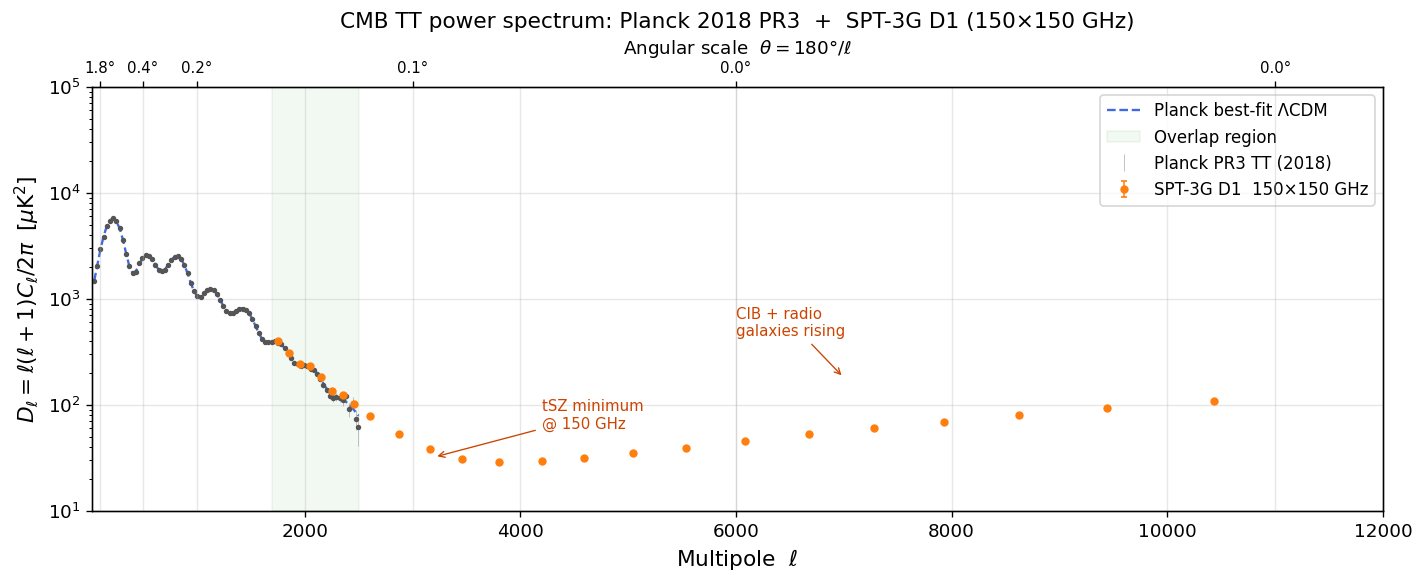

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

# ── Planck PR3 band powers (with asymmetric error bars) ──────────────────────
ax.errorbar(
    pl["ell"], pl["Dl"],
    yerr=[pl["err_lo"], pl["err_hi"]],
    fmt="none", ecolor="#aaaaaa", elinewidth=0.6, alpha=0.7,
    label="Planck PR3 TT (2018)",
)
ax.scatter(
    pl["ell"], pl["Dl"],
    s=5, color="#555555", zorder=3,
)

# ── Planck best-fit ΛCDM (extended to high ℓ as reference) ──────────────────
ax.plot(
    pl["ell"], pl["bestfit"],
    color="royalblue", lw=1.4, ls="--",
    label="Planck best-fit ΛCDM",
)

# ── SPT-3G D1 150×150 GHz ────────────────────────────────────────────────────
d150 = spt["150×150"]
ax.errorbar(
    d150["ell"], d150["Dl"], yerr=d150["sigmaDl"],
    fmt="o", ms=4, color="#ff7f0e", elinewidth=0.9,
    capsize=2, label="SPT-3G D1  150×150 GHz",
    zorder=5,
)

# ── Annotations ──────────────────────────────────────────────────────────────
ax.axvspan(1700, 2500, alpha=0.05, color="green", label="Overlap region")
ax.annotate(
    "tSZ minimum\n@ 150 GHz",
    xy=(3200, 32), xytext=(4200, 60),
    fontsize=9, color="#cc4400",
    arrowprops=dict(arrowstyle="->", color="#cc4400", lw=0.8),
)
ax.annotate(
    "CIB + radio\ngalaxies rising",
    xy=(7000, 180), xytext=(6000, 450),
    fontsize=9, color="#cc4400",
    arrowprops=dict(arrowstyle="->", color="#cc4400", lw=0.8),
)

ax.set_yscale("log")
ax.set_xlabel(r"Multipole  $\ell$", fontsize=13)
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell / 2\pi\;\;[\mu\mathrm{K}^2]$", fontsize=13)
ax.set_title(
    "CMB TT power spectrum: Planck 2018 PR3  +  SPT-3G D1 (150×150 GHz)",
    fontsize=13,
)
ax.set_xlim(30, 12000)
ax.set_ylim(10, 1e5)
ax.legend(fontsize=10, loc="upper right")

# Secondary x-axis showing angular scale θ ≈ 180°/ℓ
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_ells = [100, 500, 1000, 3000, 6000, 11000]
ax2.set_xticks(tick_ells)
ax2.set_xticklabels([f"{180/l:.1f}°" for l in tick_ells], fontsize=9)
ax2.set_xlabel(r"Angular scale  $\theta = 180°/\ell$", fontsize=11)

plt.tight_layout()
plt.savefig("spt3g_d1_planck_comparison.png", bbox_inches="tight")
plt.show()

## 5. Zoom into the overlap region

Planck measures up to $\ell \approx 2500$ and SPT-3G D1 starts at $\ell = 1700$,
giving a **~800-multipole overlap window** where both experiments should agree
on the primary CMB power.

Any systematic offset between the two would signal calibration differences
or residual foreground contamination in one (or both) data sets.

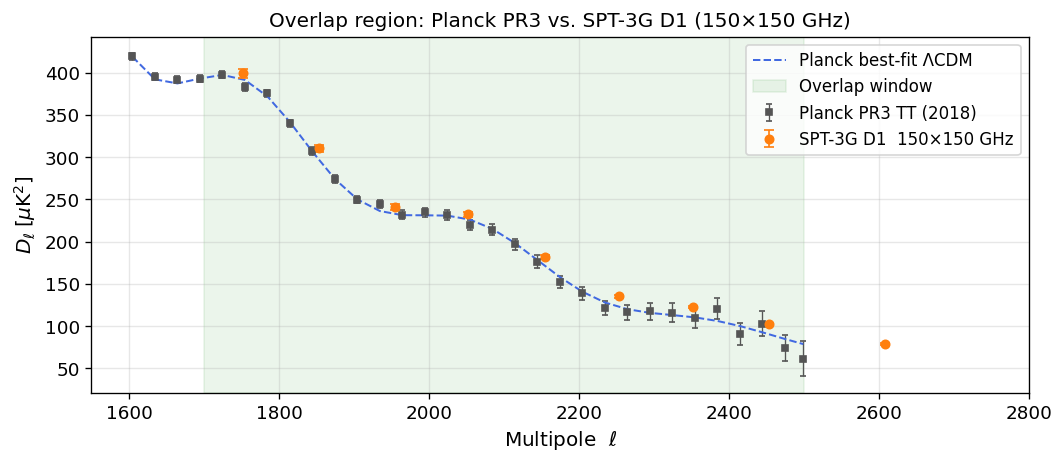

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

# Planck points in overlap range
mask_pl = pl["ell"] >= 1600
ax.errorbar(
    pl["ell"][mask_pl], pl["Dl"][mask_pl],
    yerr=[pl["err_lo"][mask_pl], pl["err_hi"][mask_pl]],
    fmt="s", ms=4, color="#555555", elinewidth=0.8, capsize=2,
    label="Planck PR3 TT (2018)",
)
ax.plot(pl["ell"][mask_pl], pl["bestfit"][mask_pl],
        color="royalblue", lw=1.2, ls="--", label="Planck best-fit ΛCDM")

# SPT-3G D1 low-ell portion
mask_spt = d150["ell"] <= 2700
ax.errorbar(
    d150["ell"][mask_spt], d150["Dl"][mask_spt],
    yerr=d150["sigmaDl"][mask_spt],
    fmt="o", ms=5, color="#ff7f0e", elinewidth=1.0, capsize=3,
    label="SPT-3G D1  150×150 GHz",
)

ax.axvspan(1700, 2500, alpha=0.08, color="green", label="Overlap window")
ax.set_xlabel(r"Multipole  $\ell$", fontsize=12)
ax.set_ylabel(r"$D_\ell\;[\mu\mathrm{K}^2]$", fontsize=12)
ax.set_title("Overlap region: Planck PR3 vs. SPT-3G D1 (150×150 GHz)", fontsize=12)
ax.set_xlim(1550, 2800)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("spt3g_d1_planck_overlap.png", bbox_inches="tight")
plt.show()

## 6. Multi-frequency view: foreground separation by frequency

A key advantage of SPT-3G D1 is the simultaneous measurement at three
frequencies. The plot below overlays all six spectra on a single panel
to illustrate frequency-dependent behaviour:

* **tSZ imprint:** the tSZ effect *decreases* the temperature at 95 and
  150 GHz (relative to the CIB) and has a spectral null at ~217 GHz.
  The 150×150 spectrum is most suppressed relative to 220×220 near ℓ ≈ 3000.
* **CIB rise:** The CIB has a steep, rising spectrum, making the 220 GHz
  channels the most CIB-dominated at high ℓ.
* **Radio galaxies:** They appear brightest at 95 GHz and their power
  remains relatively flat or slightly rising toward low ℓ within the SPT range.

These frequency dependencies allow the SPT-3G collaboration to fit for the
individual foreground components and extract, e.g., the tSZ amplitude
$D^{\mathrm{tSZ}}_{3000}$ and kSZ amplitude $D^{\mathrm{kSZ}}_{3000}$.

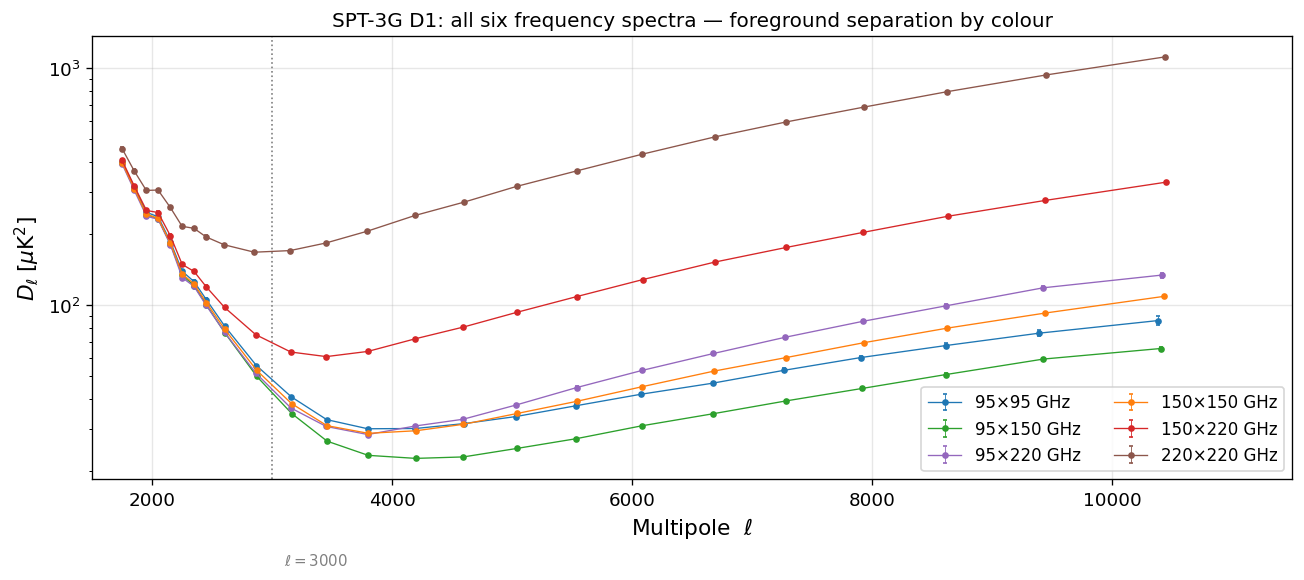

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

for name in FREQS:
    d = spt[name]
    ax.errorbar(
        d["ell"], d["Dl"], yerr=d["sigmaDl"],
        fmt="o-", ms=3, lw=0.8, color=palette[name],
        elinewidth=0.5, capsize=1, label=f"{name} GHz",
    )

# Show where tSZ roughly creates its minimum in the 150×150 spectrum
ax.axvline(3000, color="grey", ls=":", lw=1)
ax.text(3100, 8, r"$\ell = 3000$", fontsize=9, color="grey")

ax.set_yscale("log")
ax.set_xlabel(r"Multipole  $\ell$", fontsize=13)
ax.set_ylabel(r"$D_\ell\;[\mu\mathrm{K}^2]$", fontsize=13)
ax.set_title(
    "SPT-3G D1: all six frequency spectra — foreground separation by colour",
    fontsize=12,
)
ax.set_xlim(1500, 11500)
ax.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.savefig("spt3g_d1_all_spectra_overlay.png", bbox_inches="tight")
plt.show()

## 7. Key results from the paper

Chaubal et al. (2026) use these spectra to constrain the amplitudes of
the secondary signal components. Selected highlights:

| Parameter | Value | Notes |
|-----------|-------|-------|
| $D^{\mathrm{tSZ}}_{3000}$ | $4.91 \pm 0.37\;\mu\mathrm{K}^2$ | Thermal SZ at 143 GHz |
| $D^{\mathrm{kSZ}}_{3000}$ | $1.75 \pm 0.86\;\mu\mathrm{K}^2$ | Kinematic SZ |
| Duration of reionization $\Delta_{50}z_{\rm re}$ | $< 3.8$ (95%) | From kSZ |
| Duration of reionization $\Delta_{90}z_{\rm re}$ | $< 6.1$ (95%) | AMBER simulations |

The kSZ power provides the most constraining current bounds on the
epoch and duration of reionization from the small-scale CMB power spectrum.

## 8. Summary

This notebook demonstrated how to:

1. **Download** and **parse** the SPT-3G D1 band-power file from the UChicago
   public data archive and the Planck Legacy Archive (IRSA mirror).
2. **Compare** the high-resolution SPT-3G spectra with the Planck 2018 PR3
   measurements in the overlap multipole range $1700 \lesssim \ell \lesssim 2500$.
3. **Visualise** the frequency-dependent foreground signatures (tSZ minimum,
   CIB rise) that allow SPT-3G D1 to separate astrophysical components.

Together, Planck (primary CMB, large scales) and SPT-3G D1 (secondary CMB,
small scales) map the CMB temperature power spectrum across nearly four
decades in angular scale, from the Sachs–Wolfe plateau at $\ell \sim 2$ to
the Poisson-noise floor of extragalactic sources at $\ell \sim 10{,}000$.

## References

* **Chaubal P. et al. (2026)**: *SPT-3G D1: A Measurement of Secondary Cosmic
  Microwave Background Anisotropy Power*, arXiv:2601.20551,
  submitted to JCAP.
  Data: <https://pole.uchicago.edu/public/data/chaubal26/>
  (mirrored at LAMBDA: <https://lambda.gsfc.nasa.gov/product/spt/spt3g_d1_high_ell_info.html>)

* **Planck Collaboration V (2020)**: *Planck 2018 results. V. Power spectra and
  likelihoods*, A&A 641, A5.
  DOI: <https://doi.org/10.1051/0004-6361/201936386>.
  Data: Planck Legacy Archive (IRSA).

* **Sunyaev & Zel'dovich (1972)**: *The Observations of Relic Radiation as a
  Test of the Nature of X-Ray Radiation from the Clusters of Galaxies*,
  Comm. Astrophys. Space Phys. 4, 173.